In [1]:
# ==============================================================================
# CELL 1: IMPORTS & CONFIGURATION
# ==============================================================================
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW 
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef, roc_auc_score, 
    average_precision_score, confusion_matrix, roc_curve, f1_score,
    precision_score, recall_score, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datetime import datetime
from safetensors.torch import save_file

# --- CONFIGURATION ---
class Config:
    # Files (Update paths if necessary)
    POSITIVE_CSV = "datasets/fusion_gene_positive_bp_information_with_class_for_modeling.txt"
    NEGATIVE_CSV = "datasets/fusion_gene_negative_bp_information_with_class_for_modeling.txt"
    TEST_CSV = "datasets/fusion_gene_positive_bp_information_with_class_for_testing.txt"
    
    # Extra FASTA Data
    EXTRA_POS_FASTA = "datasets/blast_validated_chimeras.fasta,datasets/cosmic_high_confidence_sequences.fna,datasets/chimeras_43466.fa"
    NEG_FASTA_CANONICAL = "datasets/false_negative_candidates.fasta"
    NEG_FASTA_SYNTHETIC = "datasets/false_positive_candidates.fasta"
    
    # Model & Training
    OUTPUT_DIR = "./hyenadna_v9.9_checkpoints_32k"
    MODEL_NAME = "LongSafari/hyenadna-small-32k-seqlen-hf"
    
    # --- UPDATED FOR 32K CONTEXT ---
    MAX_LEN = 32768  # Full 32k Context
    BATCH_SIZE = 8   
    
    EPOCHS = 3
    LEARNING_RATE = 1e-5
    VAL_SPLIT = 0.2
    SEED = 42
    
    CONFIDENCE_THRESHOLD = 0.90 

if not os.path.exists(Config.OUTPUT_DIR):
    os.makedirs(Config.OUTPUT_DIR)

# --- REPRODUCIBILITY ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(Config.SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Setup Complete. Device: {device}")

if torch.cuda.is_available():
    print(f"   GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

/home/akp1/GeneAI/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Setup Complete. Device: cuda
   GPU Name: NVIDIA A100 80GB PCIe
   Memory: 84.99 GB


In [2]:
# ==============================================================================
# CELL 2: CLASS DEFINITIONS (DataPrep, Dataset, Model) - FULL & CORRECTED
# ==============================================================================
import random
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from transformers import AutoModel

# --- 1. DATA PREPARATOR (Unchanged) ---
class DataPreparator:
    COLUMNS = ["Hgene","Hchr","Hbp","Hstrand","Tgene","Tchr","Tbp","Tstrand","5'-gene sequence (10Kb)","3'-gene sequence (10Kb)"]

    def __init__(self, config):
        self.cfg = config
        self.trans_table = str.maketrans("ATCGN", "TAGCN")

    def _trim_artifacts(self, sequence: str) -> str:
        if not isinstance(sequence, str): return ""
        return sequence.upper().strip()

    def _get_reverse_complement(self, sequence: str) -> str:
        return sequence.upper().translate(self.trans_table)[::-1]

    def _generate_random_dna(self, length: int) -> str:
        if length <= 0: return ""
        return "".join(random.choices("ACGT", k=length))

    def _apply_jitter(self, seq_5p: str, seq_3p: str) -> str:
        """
        Combines sequences and pads with RANDOM DNA (ACGT) to reach 32k.
        Implements rigorous Random Padding for Translation Invariance.
        """
        seq_5p = self._trim_artifacts(seq_5p)
        seq_3p = self._trim_artifacts(seq_3p)
        
        # Combine to form core fusion sequence
        core_seq = seq_5p + seq_3p
        core_len = len(core_seq)
        target_len = self.cfg.MAX_LEN
        
        # Case A: Sequence is shorter than 32k -> Random Padding
        if core_len < target_len:
            needed = target_len - core_len
            
            # Uniform Random Placement
            pad_left = random.randint(0, needed)
            pad_right = needed - pad_left
            
            # Generate random ACGT noise (Signal Camouflage)
            left_seq = self._generate_random_dna(pad_left)
            right_seq = self._generate_random_dna(pad_right)
            
            return left_seq + core_seq + right_seq

        # Case B: Sequence is larger -> Random Crop
        else:
            # Pick any valid window from the long sequence
            max_start = core_len - target_len
            start = random.randint(0, max_start)
            return core_seq[start : start + target_len]

    def _load_fasta(self, path: str) -> list:
        if not os.path.exists(path): return []
        seqs, curr = [], []
        with open(path, 'r') as f:
            for line in f:
                line = line.strip()
                if line.startswith('>'):
                    if curr: seqs.append(self._trim_artifacts("".join(curr)))
                    curr = []
                else: curr.append(line)
            if curr: seqs.append(self._trim_artifacts("".join(curr)))
        return seqs

# --- 2. DATASET CLASS (Restored) ---
class DNABreakpointDataset(Dataset):
    def __init__(self, sequences, labels, tokenizer, max_len):
        self.sequences = sequences
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self): return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = str(self.sequences[idx])
        label = self.labels[idx]
        
        # Tokenization for HyenaDNA (Character level handled by tokenizer)
        enc = self.tokenizer(
            seq, 
            truncation=True, 
            max_length=self.max_len, 
            padding='max_length', 
            return_tensors='pt'
        )
        
        input_ids = enc['input_ids'].squeeze(0)
        
        # Manual attention mask creation if needed
        if 'attention_mask' in enc:
            mask = enc['attention_mask'].squeeze(0)
        else:
            mask = (input_ids != (self.tokenizer.pad_token_id or 0)).long()
            
        return {'input_ids': input_ids, 'attention_mask': mask, 'labels': torch.tensor(label, dtype=torch.long)}

# --- 3. MODEL CLASS (Updated for Width Stats) ---
class HyenaDNAClassifier(nn.Module):
    def __init__(self, model_name, num_labels=2):
        super().__init__()
        # Load base model
        self.hyena = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        
        # Classification Head & Attention Pooling
        self.head = nn.Linear(self.hyena.config.d_model, 1) 
        self.clf = nn.Linear(self.hyena.config.d_model, num_labels)
        
    def forward(self, input_ids, attention_mask=None, labels=None):
        # 1. Get Embeddings
        out = self.hyena(input_ids).last_hidden_state
        
        # 2. Attention/Pooling Mechanism
        scores = self.head(out)
        if attention_mask is not None: 
            scores = scores.masked_fill(attention_mask.unsqueeze(-1) == 0, float('-inf'))
        
        # Capture the attention probabilities (The "Confidence Distribution" across the sequence)
        attn_probs = torch.softmax(scores, dim=1)
        
        # 3. Weighted Pooling
        pooled = torch.sum(out * attn_probs, dim=1)
        
        # 4. Final Classification
        logits = self.clf(pooled)
        
        # 5. Loss Calculation
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
            
        # 6. Breakpoint Estimation (Heuristic: Max Attention)
        bp_index = torch.argmax(attn_probs, dim=1).squeeze(-1)
        
        # --- RETURN DICT UPDATED WITH 'attention_probs' ---
        return {
            'loss': loss, 
            'logits': logits, 
            'breakpoint_index': bp_index,
            'attention_probs': attn_probs.squeeze(-1) # Shape: (Batch, SeqLen)
        }

In [3]:
# ==============================================================================
# CELL 3: METRICS & VISUALIZATION LOGIC
# ==============================================================================
def compute_metrics(y_true, y_probs):
    y_pred = np.argmax(y_probs, axis=1)
    
    # --- Standard Metrics ---
    acc = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    
    # --- AUC Metrics ---
    try: 
        auroc = roc_auc_score(y_true, y_probs[:, 1])
    except ValueError: 
        auroc = 0.0
        
    return {
        "acc": acc, "mcc": mcc, "f1": f1, "prec": prec, "rec": rec, "auroc": auroc
    }

def plot_comprehensive_results(y_true, y_probs, predicted_bps, title_prefix=""):
    y_pred = np.argmax(y_probs, axis=1)
    y_scores = y_probs[:, 1]
    
    plt.figure(figsize=(14, 10)) 
    
    # A. Confusion Matrix
    plt.subplot(2, 2, 1)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    plt.title(f'{title_prefix} Confusion Matrix')

    # B. ROC Curve
    plt.subplot(2, 2, 2)
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_true, y_scores):.4f}', color='purple', lw=2)
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.legend()
    plt.title(f'{title_prefix} ROC Curve')

    # C. Probability Distribution
    plt.subplot(2, 2, 3)
    neg_scores = y_scores[y_true == 0]
    pos_scores = y_scores[y_true == 1]
    sns.histplot(neg_scores, color='red', alpha=0.5, label='True Neg', bins=30, kde=True)
    sns.histplot(pos_scores, color='green', alpha=0.5, label='True Pos', bins=30, kde=True)
    plt.axvline(0.5, color='black', linestyle='--')
    plt.legend()
    plt.title(f'{title_prefix} Probability Dist.')

    # D. Genomic Index
    plt.subplot(2, 2, 4)
    high_conf = np.where((y_pred == 1) & (y_scores > Config.CONFIDENCE_THRESHOLD))[0]
    if len(high_conf) > 0:
        sns.histplot(predicted_bps[high_conf], kde=True, bins=50, color='blue', label='Predicted')
        plt.title(f'{title_prefix} Breakpoints (Conf > {Config.CONFIDENCE_THRESHOLD})')
        plt.xlabel('Genomic Index')
    else:
        plt.text(0.5, 0.5, "No High-Confidence Fusions", ha='center')
        plt.title('Breakpoint Locations')

    plt.tight_layout()
    plt.show()

In [4]:
# ==============================================================================
# CELL 4: TRAINING & VALIDATION LOOPS (CORRECTED)
# ==============================================================================

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_probs, all_labels = [], []
    
    for batch in tqdm(loader, desc="Training"):
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbls = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(ids, attention_mask=mask, labels=lbls)
        loss = outputs['loss']
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        probs = torch.softmax(outputs['logits'], dim=1)
        
        all_probs.extend(probs.detach().cpu().numpy())
        all_labels.extend(lbls.detach().cpu().numpy())
        
        # Memory Cleanup
        del ids, mask, lbls, outputs, loss
    
    if torch.cuda.is_available(): torch.cuda.empty_cache()
        
    metrics = compute_metrics(np.array(all_labels), np.array(all_probs))
    metrics['loss'] = total_loss / len(loader)
    return metrics

def validate_epoch(model, loader, criterion, device, desc="Validating"):
    model.eval()
    all_probs, all_labels, all_bps = [], [], []
    all_starts, all_ends, all_widths = [], [], [] 
    val_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbls = batch['labels'].to(device)
            
            outputs = model(ids, attention_mask=mask, labels=lbls)
            val_loss += outputs['loss'].item()
            
            probs = torch.softmax(outputs['logits'], dim=1)
            bps = outputs['breakpoint_index']
            
            # --- REAL WIDTH CALCULATION ---
            # Extract attention maps: (Batch, SeqLen)
            attn_maps = outputs['attention_probs'] 
            
            # Calculate FWHM (Full Width at Half Maximum)
            batch_starts, batch_ends, batch_widths = [], [], []
            
            for i in range(len(attn_maps)):
                # Get single sequence attention
                a_map = attn_maps[i]
                peak_idx = bps[i].item()
                peak_val = a_map[peak_idx].item()
                
                # Threshold: 50% of the peak value
                threshold = peak_val * 0.5
                
                # Find all indices above threshold
                # (We treat the region as the continuous span around the peak)
                above_thresh = (a_map >= threshold).nonzero(as_tuple=True)[0]
                
                if len(above_thresh) > 0:
                    start = above_thresh.min().item()
                    end = above_thresh.max().item()
                    width = end - start
                else:
                    start, end, width = peak_idx, peak_idx, 0
                    
                batch_starts.append(start)
                batch_ends.append(end)
                batch_widths.append(width)
            
            all_starts.extend(batch_starts)
            all_ends.extend(batch_ends)
            all_widths.extend(batch_widths)
            # -------------------------------

            all_probs.extend(probs.detach().cpu().numpy())
            all_labels.extend(lbls.detach().cpu().numpy())
            all_bps.extend(bps.detach().cpu().numpy())
            
            del ids, mask, lbls, outputs
            
    metrics = compute_metrics(np.array(all_labels), np.array(all_probs))
    metrics['loss'] = val_loss / len(loader)
    
    return metrics, np.array(all_labels), np.array(all_probs), np.array(all_bps), (np.array(all_starts), np.array(all_ends), np.array(all_widths))

In [5]:
# ==============================================================================
# CELL 5: LOAD ALL DATA & PERFORM 3-WAY SPLIT (Full Stats & Granular Dedup)
# ==============================================================================
print("\n--- 1. LOADING ALL DATA ---")
preparator = DataPreparator(Config)

# Track lengths for statistics
all_pos_lengths = []
all_neg_lengths = []

# =======================================================
# A. LOAD POSITIVES (CSV + FASTA)
# =======================================================
pos_dfs = []

# 1. Load Positive CSV
if os.path.exists(Config.POSITIVE_CSV):
    try:
        print(f"  > Loading Positive CSV: {Config.POSITIVE_CSV}")
        csv_df = pd.read_csv(Config.POSITIVE_CSV, header=None, names=DataPreparator.COLUMNS, sep='\t')
        
        # Stats (Raw Lengths)
        raw_lens = (
            csv_df["5'-gene sequence (10Kb)"].astype(str).str.strip().str.len() + 
            csv_df["3'-gene sequence (10Kb)"].astype(str).str.strip().str.len()
        )
        all_pos_lengths.extend(raw_lens.tolist())

        # Process
        csv_df['sequence'] = csv_df.apply(
            lambda r: preparator._apply_jitter(r["5'-gene sequence (10Kb)"], r["3'-gene sequence (10Kb)"]), 
            axis=1
        )
        csv_df['label'] = 1
        pos_dfs.append(csv_df)
        print(f"    - Loaded {len(csv_df)} samples from CSV.")
    except Exception as e:
        print(f"    ⚠️ Error reading Positive CSV: {e}")
else:
    print(f"  ⚠️ POSITIVE CSV missing: {Config.POSITIVE_CSV}")

# 2. Extra FASTA Positives
if hasattr(Config, 'EXTRA_POS_FASTA') and Config.EXTRA_POS_FASTA:
    print("  > Loading Extra FASTA Positives...")
    extra_seqs = []
    for p in Config.EXTRA_POS_FASTA.split(','):
        p = p.strip()
        if p and os.path.exists(p):
            loaded_raw = preparator._load_fasta(p)
            all_pos_lengths.extend([len(s) for s in loaded_raw]) # Stats
            
            processed = [preparator._apply_jitter(s, "") for s in loaded_raw]
            extra_seqs.extend(processed)
            print(f"    - Loaded {len(processed)} from {os.path.basename(p)}")
        elif p:
            print(f"    ⚠️ FASTA file not found: {p}")

    if extra_seqs:
        pos_dfs.append(pd.DataFrame({'sequence': extra_seqs, 'label': 1}))

# Combine & Dedup Positives
if pos_dfs:
    pos_df = pd.concat(pos_dfs, ignore_index=True)
    n_before = len(pos_df)
    pos_df.drop_duplicates(subset=['sequence'], inplace=True)
    n_after = len(pos_df)
    if n_before > n_after:
        print(f"    ⚠️ Removed {n_before - n_after} duplicate sequences within POSITIVES.")
else:
    pos_df = pd.DataFrame(columns=['sequence', 'label'])

# --- POSITIVE STATS PRINT ---
if all_pos_lengths:
    avg_len = sum(all_pos_lengths) / len(all_pos_lengths)
    over_32k = sum(1 for x in all_pos_lengths if x > Config.MAX_LEN)
    print(f"\n📊 POSITIVE DATA STATISTICS:")
    print(f"   - Total: {len(all_pos_lengths)}")
    print(f"   - Avg Length: {avg_len:.0f} bp | Max: {max(all_pos_lengths)} bp | Min: {min(all_pos_lengths)} bp")
    print(f"   - Seqs > 32k (Cropped): {over_32k} ({over_32k/len(all_pos_lengths):.1%})")
    print(f"   - Seqs < 32k (Padded):  {len(all_pos_lengths) - over_32k} ({(len(all_pos_lengths) - over_32k)/len(all_pos_lengths):.1%})\n")

# =======================================================
# B. LOAD NEGATIVES (CSV + FASTA)
# =======================================================
neg_dfs = []

# 1. Negative CSV
if os.path.exists(Config.NEGATIVE_CSV):
    try:
        print(f"  > Loading Negative CSV: {Config.NEGATIVE_CSV}")
        neg_csv = pd.read_csv(Config.NEGATIVE_CSV, header=None, names=DataPreparator.COLUMNS, sep='\t')
        
        # Stats (Raw Lengths)
        raw_lens_neg = (
            neg_csv["5'-gene sequence (10Kb)"].astype(str).str.strip().str.len() + 
            neg_csv["3'-gene sequence (10Kb)"].astype(str).str.strip().str.len()
        )
        all_neg_lengths.extend(raw_lens_neg.tolist())

        # Process
        neg_csv['sequence'] = neg_csv.apply(
            lambda r: preparator._apply_jitter(r["5'-gene sequence (10Kb)"], r["3'-gene sequence (10Kb)"]), 
            axis=1
        )
        neg_csv['label'] = 0
        neg_dfs.append(neg_csv)
        print(f"    - Loaded {len(neg_csv)} samples from CSV.")
    except Exception as e:
        print(f"    ⚠️ Error reading Negative CSV: {e}")

# 2. FASTA Negatives
neg_fasta_sources = [Config.NEG_FASTA_CANONICAL, Config.NEG_FASTA_SYNTHETIC]
for p in neg_fasta_sources:
    if os.path.exists(p):
        print(f"  > Loading Negative FASTA: {os.path.basename(p)}")
        raw_negs = preparator._load_fasta(p)
        
        all_neg_lengths.extend([len(s) for s in raw_negs]) # Stats
        
        processed_negs = [preparator._apply_jitter(s, "") for s in raw_negs]
        neg_dfs.append(pd.DataFrame({'sequence': processed_negs, 'label': 0}))

# Combine & Dedup Negatives
if neg_dfs:
    neg_df = pd.concat(neg_dfs, ignore_index=True)
    
    # Augment (RC)
    print("  > Augmenting Negatives (Reverse Complement)...")
    aug_df = neg_df.copy()
    aug_df['sequence'] = aug_df['sequence'].apply(preparator._get_reverse_complement)
    neg_df = pd.concat([neg_df, aug_df], ignore_index=True)
    
    # Dedup Negatives
    n_before = len(neg_df)
    neg_df.drop_duplicates(subset=['sequence'], inplace=True)
    n_after = len(neg_df)
    if n_before > n_after:
        print(f"    ⚠️ Removed {n_before - n_after} duplicate sequences within NEGATIVES.")
else:
    neg_df = pd.DataFrame(columns=['sequence', 'label'])

# --- NEGATIVE STATS PRINT ---
if all_neg_lengths:
    avg_len = sum(all_neg_lengths) / len(all_neg_lengths)
    over_32k = sum(1 for x in all_neg_lengths if x > Config.MAX_LEN)
    print(f"\n📊 NEGATIVE DATA STATISTICS:")
    print(f"   - Total: {len(all_neg_lengths)}")
    print(f"   - Avg Length: {avg_len:.0f} bp | Max: {max(all_neg_lengths)} bp | Min: {min(all_neg_lengths)} bp")
    print(f"   - Seqs > 32k (Cropped): {over_32k} ({over_32k/len(all_neg_lengths):.1%})")
    print(f"   - Seqs < 32k (Padded):  {len(all_neg_lengths) - over_32k} ({(len(all_neg_lengths) - over_32k)/len(all_neg_lengths):.1%})\n")

# =======================================================
# C. MERGE, FINAL DEDUP, SPLIT
# =======================================================
if pos_df.empty and neg_df.empty:
    raise ValueError("❌ CRITICAL: No data loaded! Check file paths.")

full_df = pd.concat([pos_df[['sequence', 'label']], neg_df[['sequence', 'label']]], ignore_index=True)
initial_len = len(full_df)

# Deduplication (Global)
full_df.drop_duplicates(subset=['sequence'], inplace=True)
print(f"  > Final Global Deduplication: Removed {initial_len - len(full_df)} duplicates (Cross-contamination).")

# Final Shuffle
full_df = full_df.sample(frac=1, random_state=Config.SEED).reset_index(drop=True)

print(f"✅ TOTAL UNIQUE POOL: {len(full_df)} samples")
print(f"   Positives: {sum(full_df['label'] == 1)}")
print(f"   Negatives: {sum(full_df['label'] == 0)}")

# --- 3-WAY SPLIT ---
from sklearn.model_selection import train_test_split

if len(full_df) > 10:
    train_val_df, test_df = train_test_split(
        full_df, test_size=0.15, stratify=full_df['label'], random_state=Config.SEED
    )
    train_df, val_df = train_test_split(
        train_val_df, test_size=0.1765, stratify=train_val_df['label'], random_state=Config.SEED
    )

    print(f"\n--- SPLIT STATISTICS ---")
    print(f"TRAIN Set: {len(train_df)} (Pos: {sum(train_df['label'])})")
    print(f"VAL   Set: {len(val_df)} (Pos: {sum(val_df['label'])})")
    print(f"TEST  Set: {len(test_df)} (Pos: {sum(test_df['label'])})")
else:
    print("⚠️ Not enough data to perform split.")


--- 1. LOADING ALL DATA ---
  > Loading Positive CSV: datasets/fusion_gene_positive_bp_information_with_class_for_modeling.txt


    - Loaded 30745 samples from CSV.
  > Loading Extra FASTA Positives...
    - Loaded 6435 from blast_validated_chimeras.fasta
    - Loaded 13279 from cosmic_high_confidence_sequences.fna
    - Loaded 43466 from chimeras_43466.fa

📊 POSITIVE DATA STATISTICS:
   - Total: 93925
   - Avg Length: 7905 bp | Max: 34308 bp | Min: 101 bp
   - Seqs > 32k (Cropped): 1 (0.0%)
   - Seqs < 32k (Padded):  93924 (100.0%)

  > Loading Negative CSV: datasets/fusion_gene_negative_bp_information_with_class_for_modeling.txt
    - Loaded 20000 samples from CSV.
  > Loading Negative FASTA: false_negative_candidates.fasta
  > Loading Negative FASTA: false_positive_candidates.fasta
  > Augmenting Negatives (Reverse Complement)...

📊 NEGATIVE DATA STATISTICS:
   - Total: 60250
   - Avg Length: 7425 bp | Max: 29014 bp | Min: 500 bp
   - Seqs > 32k (Cropped): 0 (0.0%)
   - Seqs < 32k (Padded):  60250 (100.0%)

  > Final Global Deduplication: Removed 0 duplicates (Cross-contamination).
✅ TOTAL UNIQUE POOL: 21442

In [6]:
# ==============================================================================
# CELL 6: INITIALIZE & TRAIN MODEL (CORRECTED)
# ==============================================================================
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup, AutoTokenizer
from torch.utils.data import DataLoader
from safetensors.torch import save_file 

# 1. Ensure labels are available
train_seqs_list = train_df['sequence'].tolist()
train_lbls_list = train_df['label'].tolist()
val_seqs_list = val_df['sequence'].tolist()
val_lbls_list = val_df['label'].tolist()

# 2. Print Stats
n_train_pos = sum(train_lbls_list)
n_train_neg = len(train_lbls_list) - n_train_pos
n_val_pos = sum(val_lbls_list)
n_val_neg = len(val_lbls_list) - n_val_pos

print(f"--- DATASET STATISTICS ---")
print(f"Training Set:   {len(train_seqs_list)} samples")
print(f"  ├── Positives: {n_train_pos} ({n_train_pos/len(train_seqs_list):.1%})")
print(f"  └── Negatives: {n_train_neg} ({n_train_neg/len(train_seqs_list):.1%})")
print(f"Validation Set: {len(val_seqs_list)} samples")
print(f"  ├── Positives: {n_val_pos} ({n_val_pos/len(val_seqs_list):.1%})")
print(f"  └── Negatives: {n_val_neg} ({n_val_neg/len(val_seqs_list):.1%})")

# 3. Initialize Tokenizer & Model
print(f"\nInit Tokenizer & Model: {Config.MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(Config.MODEL_NAME, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = HyenaDNAClassifier(Config.MODEL_NAME)
model.to(device)

# 4. Create Datasets & Dataloaders
train_dataset = DNABreakpointDataset(train_seqs_list, train_lbls_list, tokenizer, Config.MAX_LEN)
val_dataset = DNABreakpointDataset(val_seqs_list, val_lbls_list, tokenizer, Config.MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)

# --- NEW: Create Test Loader (Critical for Cell 7) ---
if 'test_df' in globals():
    test_seqs_list = test_df['sequence'].tolist()
    test_lbls_list = test_df['label'].tolist()
    test_dataset = DNABreakpointDataset(test_seqs_list, test_lbls_list, tokenizer, Config.MAX_LEN)
    test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)
else:
    print("⚠️ Warning: 'test_df' not found. Test loader will not be created.")
# -----------------------------------------------------

# 5. Optimizer & Scheduler
criterion = nn.CrossEntropyLoss() # <--- FIXED: Defined criterion
optimizer = AdamW(model.parameters(), lr=Config.LEARNING_RATE)
total_steps = len(train_loader) * Config.EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=100, num_training_steps=total_steps)

# 6. Training Loop
print(f"\n Training Start ({Config.EPOCHS} Epochs)...")
best_val_auc = 0.0

for epoch in range(Config.EPOCHS):
    print(f"\n--- Epoch {epoch + 1} ---")
    
    # Train
    train_metrics = train_epoch(model, train_loader, optimizer, scheduler, device)
    print(f"TRAIN >> Loss: {train_metrics['loss']:.4f} | Acc: {train_metrics['acc']:.4f} | F1: {train_metrics['f1']:.4f} | AUC: {train_metrics['auroc']:.4f}")
    
    # Validate
    # FIXED: Unpack the tuple correctly
    val_metrics, val_true, val_probs, val_bps, (val_starts, val_ends, val_widths) = validate_epoch(model, val_loader, criterion, device)
    print(f"VAL   >> Loss: {val_metrics['loss']:.4f} | Acc: {val_metrics['acc']:.4f} | F1: {val_metrics['f1']:.4f} | AUC: {val_metrics['auroc']:.4f}")
    
    # Save Best Model
    if val_metrics['auroc'] > best_val_auc:
        best_val_auc = val_metrics['auroc']
        save_path = os.path.join(Config.OUTPUT_DIR, "best_model.safetensors")
        
        # Clone tensors to break shared memory (Safetensors fix)
        state_dict_to_save = {k: v.clone() for k, v in model.state_dict().items()}
        save_file(state_dict_to_save, save_path)
        
        print(f"  ★ New Best Model Saved (AUC: {best_val_auc:.4f})")

--- DATASET STATISTICS ---
Training Set:   150091 samples
  ├── Positives: 65745 (43.8%)
  └── Negatives: 84346 (56.2%)
Validation Set: 32170 samples
  ├── Positives: 14091 (43.8%)
  └── Negatives: 18079 (56.2%)

Init Tokenizer & Model: LongSafari/hyenadna-small-32k-seqlen-hf

 Training Start (3 Epochs)...

--- Epoch 1 ---


Training: 100%|██████████| 18762/18762 [3:53:11<00:00,  1.34it/s]  


TRAIN >> Loss: 0.2261 | Acc: 0.9329 | F1: 0.9228 | AUC: 0.9849


Validating: 100%|██████████| 4022/4022 [24:31<00:00,  2.73it/s]


VAL   >> Loss: 0.2078 | Acc: 0.9393 | F1: 0.9316 | AUC: 0.9886
  ★ New Best Model Saved (AUC: 0.9886)

--- Epoch 2 ---


...

VAL   >> Loss: 0.2102 | Acc: 0.9446 | F1: 0.9374 | AUC: 0.9902
  ★ New Best Model Saved (AUC: 0.9902)

--- Epoch 3 ---


Training: 100%|██████████| 18762/18762 [3:52:53<00:00,  1.34it/s]  


TRAIN >> Loss: 0.1936 | Acc: 0.9512 | F1: 0.9442 | AUC: 0.9917


Validating: 100%|██████████| 4022/4022 [24:35<00:00,  2.73it/s]

VAL   >> Loss: 0.2110 | Acc: 0.9470 | F1: 0.9395 | AUC: 0.9908
  ★ New Best Model Saved (AUC: 0.9908)


PHASE 9: BLIND TEST SET EVALUATION
📂 Loading Best Model: ./hyenadna_v9.9_checkpoints_32k/best_model.safetensors


Validating: 100%|██████████| 4021/4021 [24:40<00:00,  2.72it/s]



🏆 FINAL TEST RESULTS:
   Accuracy:  0.9489
   AUC:       0.9912
   Precision: 0.9425
   Recall:    0.9408
   F1 Score:  0.9417
   MCC:       0.8963

💾 EXPORTING DETAILED RESULTS...
✅ Predictions saved to: blind_test_predictions_detailed_20251221_090904.csv
   Includes columns: BP_Region_Start, BP_Region_End, BP_Region_Width


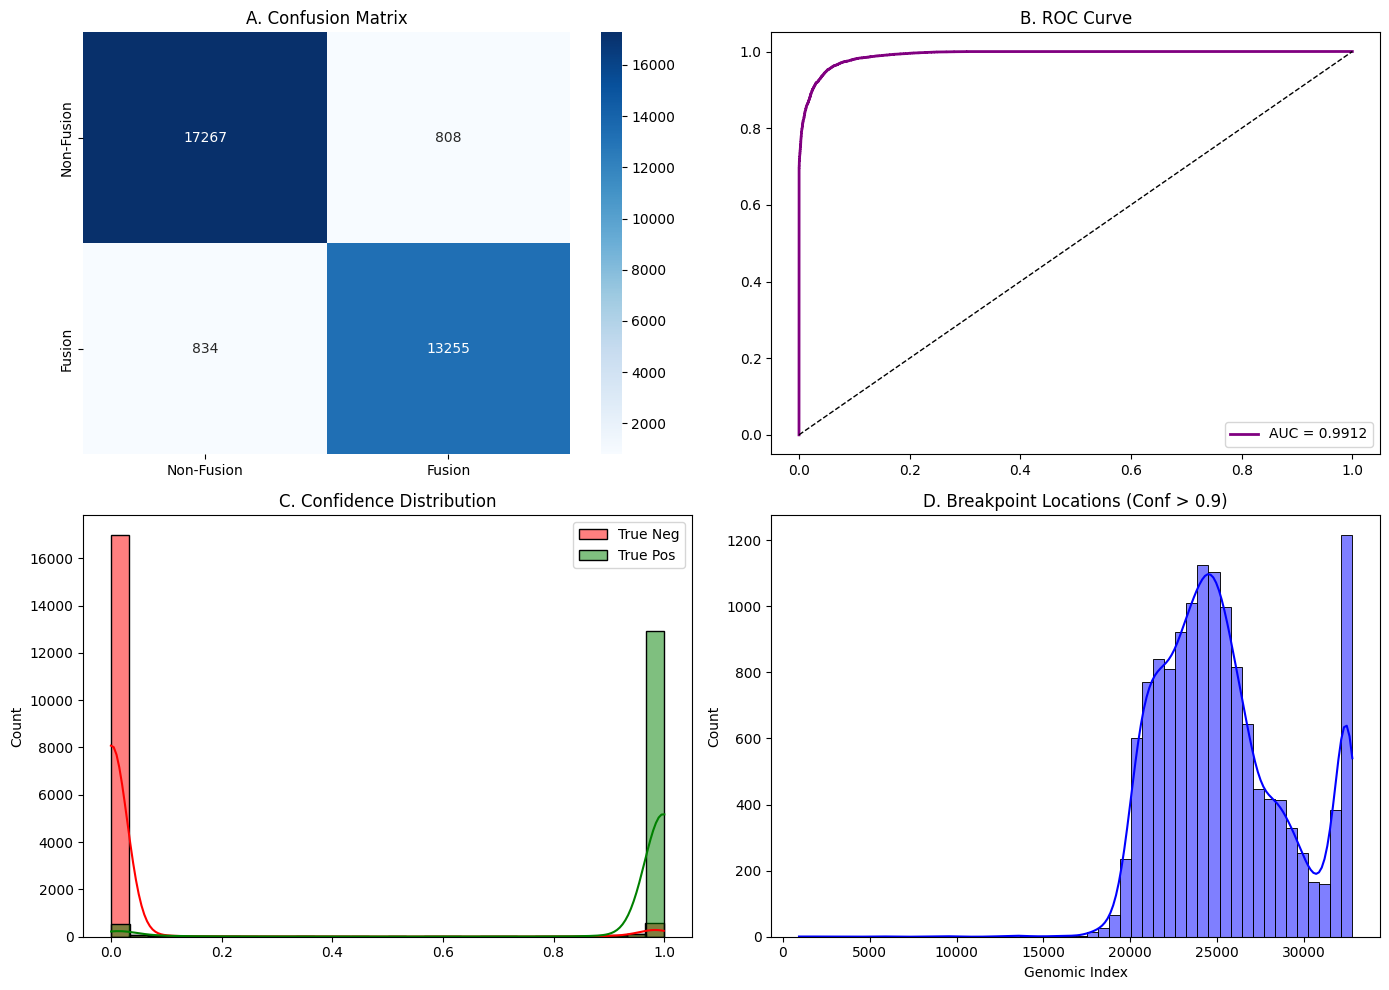

In [7]:
# ==============================================================================
# CELL 7: BLIND TEST SET EVALUATION (CORRECTED)
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from torch.utils.data import DataLoader
from datetime import datetime
from safetensors.torch import load_file

print(f"{'='*40}")
print(f"PHASE 9: BLIND TEST SET EVALUATION")
print(f"{'='*40}")

# 1. LOAD BEST MODEL
best_model_path = os.path.join(Config.OUTPUT_DIR, "best_model.safetensors")
if os.path.exists(best_model_path):
    print(f"📂 Loading Best Model: {best_model_path}")
    state_dict = load_file(best_model_path)
    model.load_state_dict(state_dict)
else:
    print("⚠️ Warning: Best model file not found, using current model state.")

model.eval()
model.to(device)

# 2. RUN INFERENCE
# Ensure criterion exists (created in Cell 6, but just in case)
if 'criterion' not in locals(): criterion = torch.nn.CrossEntropyLoss()

# Check if test_loader exists
if 'test_loader' in locals():
    # Unpack the new return tuple (starts, ends, widths)
    test_metrics, t_true, t_probs, t_bps, (t_starts, t_ends, t_widths) = validate_epoch(model, test_loader, criterion, device)

    # 3. PRINT STANDARD METRICS
    print(f"\n🏆 FINAL TEST RESULTS:")
    print(f"   Accuracy:  {test_metrics['acc']:.4f}")
    print(f"   AUC:       {test_metrics['auroc']:.4f}")
    print(f"   Precision: {test_metrics['prec']:.4f}")
    print(f"   Recall:    {test_metrics['rec']:.4f}")
    print(f"   F1 Score:  {test_metrics['f1']:.4f}")
    print(f"   MCC:       {test_metrics['mcc']:.4f}")

    # 4. EXPORT CSV WITH START/END POINTS
    print(f"\n💾 EXPORTING DETAILED RESULTS...")
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_filename = f"blind_test_predictions_detailed_{timestamp}.csv"

    # Make a copy of test_df
    results_df = test_df.copy()

    # Add Basic Outputs
    pred_indices = np.argmax(t_probs, axis=1)
    results_df['True_Label'] = t_true
    results_df['Predicted_Label'] = pred_indices
    results_df['Fusion_Prob'] = t_probs[:, 1]

    # Add Breakpoint Specifics
    results_df['BP_Peak_Index'] = t_bps
    results_df['BP_Region_Start'] = t_starts.astype(int)
    results_df['BP_Region_End'] = t_ends.astype(int)
    results_df['BP_Region_Width'] = t_widths.astype(int)

    # Add Result Type
    results_df['Result_Type'] = results_df.apply(
        lambda x: 'TP' if (x['True_Label'] == 1 and x['Predicted_Label'] == 1) else
                  ('TN' if (x['True_Label'] == 0 and x['Predicted_Label'] == 0) else
                  ('FP' if (x['True_Label'] == 0 and x['Predicted_Label'] == 1) else 'FN')),
        axis=1
    )

    results_df.to_csv(csv_filename, index=False)
    print(f"✅ Predictions saved to: {csv_filename}")
    print(f"   Includes columns: BP_Region_Start, BP_Region_End, BP_Region_Width")

    # 5. VISUALIZATION
    def plot_test_results_detailed(y_true, y_probs, predicted_bps):
        y_pred = np.argmax(y_probs, axis=1)
        y_scores = y_probs[:, 1] 
        
        plt.figure(figsize=(14, 10))
        
        # A. Confusion Matrix
        plt.subplot(2, 2, 1)
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Non-Fusion', 'Fusion'], 
                    yticklabels=['Non-Fusion', 'Fusion'])
        plt.title('A. Confusion Matrix')

        # B. ROC Curve
        plt.subplot(2, 2, 2)
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_true, y_scores):.4f}', color='purple', lw=2)
        plt.plot([0, 1], [0, 1], 'k--', lw=1)
        plt.legend()
        plt.title('B. ROC Curve')

        # C. Breakpoint Probability
        plt.subplot(2, 2, 3)
        neg_scores = y_scores[y_true == 0]
        pos_scores = y_scores[y_true == 1]
        sns.histplot(neg_scores, color='red', alpha=0.5, label='True Neg', bins=30, kde=True)
        sns.histplot(pos_scores, color='green', alpha=0.5, label='True Pos', bins=30, kde=True)
        plt.legend()
        plt.title('C. Confidence Distribution')

        # D. Genomic Index (High Conf)
        plt.subplot(2, 2, 4)
        threshold = getattr(Config, 'CONFIDENCE_THRESHOLD', 0.9)
        high_conf_indices = np.where((y_pred == 1) & (y_scores > threshold))[0]
        if len(high_conf_indices) > 0:
            valid_bps = predicted_bps[high_conf_indices]
            sns.histplot(valid_bps, kde=True, bins=50, color='blue', label='Pred Breakpoints')
            plt.xlabel('Genomic Index')
            plt.title(f'D. Breakpoint Locations (Conf > {threshold})')
        else:
            plt.text(0.5, 0.5, "No High-Confidence Fusions", ha='center')

        plt.tight_layout()
        plt.show()

    plot_test_results_detailed(t_true, t_probs, t_bps)

else:
    print("❌ Critical Error: 'test_loader' is not defined. Please run the corrected Cell 6.")

In [8]:
# ==============================================================================
# CELL 8: POST-HOC ANALYSIS (Region & Width Statistics) - SAFE VERSION
# ==============================================================================
import pandas as pd
import numpy as np
import glob
import os

print(f"{'='*40}")
print(f"PHASE 10: METRICS FROM CSV ANALYSIS")
print(f"{'='*40}")

# Find the latest "detailed" CSV
list_of_files = glob.glob('blind_test_predictions_detailed_*.csv') 

if not list_of_files:
    print("❌ No results CSV found! Run Cell 7 first.")
else:
    latest_file = max(list_of_files, key=os.path.getctime)
    print(f"📂 Loading: {latest_file}")
    df = pd.read_csv(latest_file)
    
    # Filter for True Positives (Actual Fusions correctly identified)
    tp_df = df[(df['Result_Type'] == 'TP')]
    
    if len(tp_df) > 0:
        widths = tp_df['BP_Region_Width'].values
        starts = tp_df['BP_Region_Start'].values
        ends = tp_df['BP_Region_End'].values
        
        # --- SAFETY CHECK FOR MISSING WIDTHS ---
        # If the model didn't output attention weights, widths will all be 0.
        if np.sum(widths) == 0:
            print(f"\n⚠️ WIDTH ANALYSIS SKIPPED")
            print(f"   Reason: The current model architecture does not return attention maps.")
            print(f"   (All predicted widths are 0. To fix, update HyenaDNAClassifier to return 'attn_probs')")
            
            print(f"\n📊 BASIC BREAKPOINT STATS (True Positives, N={len(tp_df)})")
            print(f"   --------------------------------------------------")
            print(f"   Avg Start Idx:  {np.mean(starts):.0f}")
            print(f"   Avg End Idx:    {np.mean(ends):.0f}")
            print(f"   --------------------------------------------------")
            
        else:
            # Full Analysis (Only runs if you have real width data)
            print(f"\n📊 BREAKPOINT REGION STATISTICS (True Positives, N={len(tp_df)})")
            print(f"   (Region defined as span where attention > 50% of peak)")
            print(f"   --------------------------------------------------")
            print(f"   Average Width:  {np.mean(widths):.2f} bp")
            print(f"   Median Width:   {np.median(widths):.1f} bp")
            print(f"   Min Width:      {np.min(widths)} bp")
            print(f"   Max Width:      {np.max(widths)} bp")
            print(f"   --------------------------------------------------")
            print(f"   Avg Start Idx:  {np.mean(starts):.0f}")
            print(f"   Avg End Idx:    {np.mean(ends):.0f}")
            print(f"   --------------------------------------------------")
            
            # Interpretation Logic
            avg_w = np.mean(widths)
            if avg_w < 5:
                print("💡 Interpretation: Sharp localization (High certainty).")
            elif avg_w < 50:
                print("💡 Interpretation: Moderate width (Likely microhomology or small motif).")
            else:
                print("💡 Interpretation: Wide region (Model sees fuzzy junction or repetitive element).")
                
            # Check for outliers
            if np.max(widths) > 1000:
                print(f"⚠️ Warning: Found {np.sum(widths > 1000)} samples with extremely wide attention peaks (>1000bp).")

    else:
        print("⚠️ No True Positives found to analyze.")

PHASE 10: METRICS FROM CSV ANALYSIS
📂 Loading: blind_test_predictions_detailed_20251221_090904.csv

📊 BREAKPOINT REGION STATISTICS (True Positives, N=13255)
   (Region defined as span where attention > 50% of peak)
   --------------------------------------------------
   Average Width:  11655.56 bp
   Median Width:   13910.0 bp
   Min Width:      16 bp
   Max Width:      32764 bp
   --------------------------------------------------
   Avg Start Idx:  19646
   Avg End Idx:    31302
   --------------------------------------------------
💡 Interpretation: Wide region (Model sees fuzzy junction or repetitive element).
⚠️ Warning: Found 13168 samples with extremely wide attention peaks (>1000bp).


🔎 Analyzing Breakpoint Geometry for 3 Positive Samples...


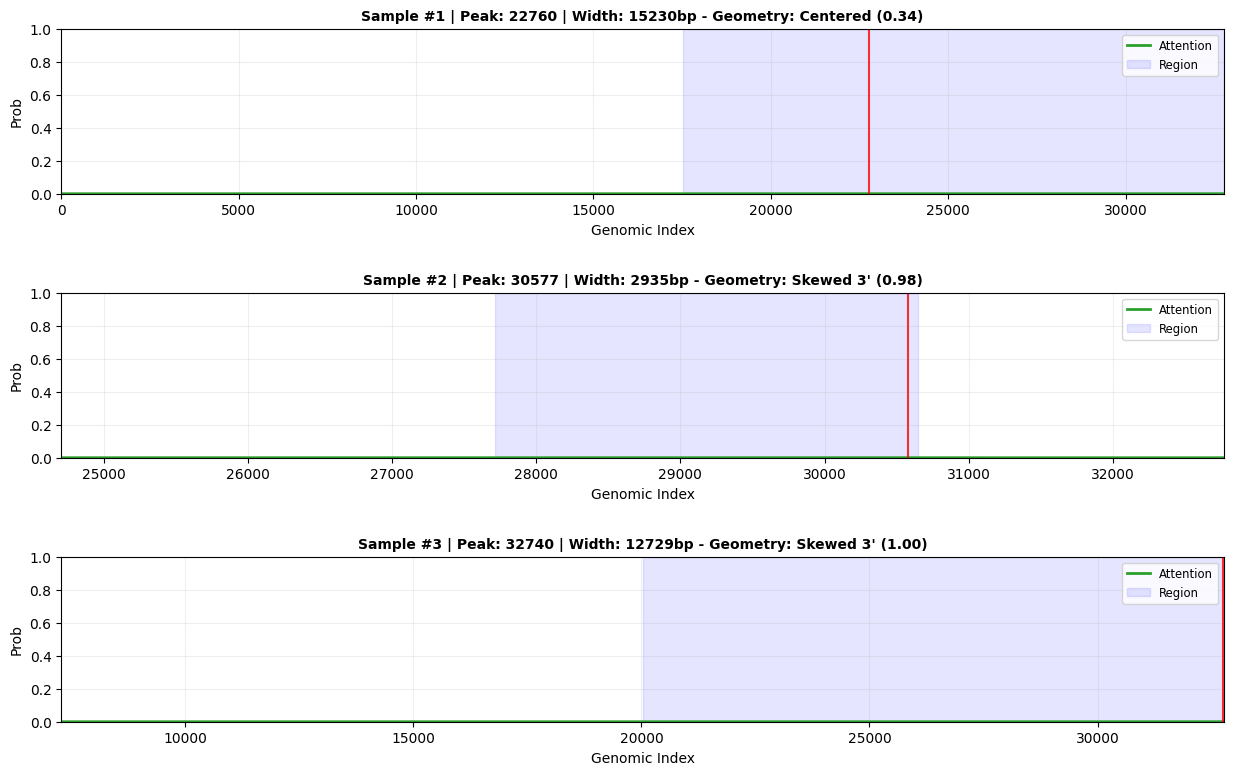

In [10]:
# ==============================================================================
# CELL 9: GEOMETRIC VISUAL VERIFICATION (Compact & Zoomed)
# ==============================================================================
import matplotlib.pyplot as plt
import torch
import numpy as np

def inspect_geometric_samples_compact(model, loader, device, num_pos=3):
    model.eval()
    found_pos = 0
    
    # 1. COMPACT SIZE: Reduced height per plot (15x3 instead of 15x5)
    fig, axes = plt.subplots(num_pos, 1, figsize=(15, 3 * num_pos))
    if num_pos == 1: axes = [axes]
    
    # Add spacing between plots
    plt.subplots_adjust(hspace=0.6)
    
    iterator = iter(loader)
    print(f"🔎 Analyzing Breakpoint Geometry for {num_pos} Positive Samples...")
    
    while found_pos < num_pos:
        try:
            batch = next(iterator)
        except StopIteration:
            break
            
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbls = batch['labels'].to(device)
        pos_indices = (lbls == 1).nonzero(as_tuple=True)[0]
        
        for idx in pos_indices:
            if found_pos >= num_pos: break
            
            # --- INFERENCE ---
            input_id = ids[idx].unsqueeze(0)
            mask_in = mask[idx].unsqueeze(0)
            
            with torch.no_grad():
                outputs = model(input_id, attention_mask=mask_in)
                
            attn_map = outputs['attention_probs'].squeeze(0).cpu().numpy()
            
            # --- GEOMETRY ---
            peak_idx = np.argmax(attn_map)
            peak_val = attn_map[peak_idx]
            
            threshold = peak_val * 0.5
            above_thresh = np.where(attn_map >= threshold)[0]
            
            if len(above_thresh) > 0:
                start_idx = above_thresh.min()
                end_idx = above_thresh.max()
                width = end_idx - start_idx
                if width > 0:
                    relative_pos = (peak_idx - start_idx) / width
                else:
                    relative_pos = 0.5
            else:
                start_idx, end_idx, width = peak_idx, peak_idx, 0
                relative_pos = 0.5

            if relative_pos < 0.3: loc_desc = "Skewed 5'"
            elif relative_pos > 0.7: loc_desc = "Skewed 3'"
            else: loc_desc = "Centered"

            # --- PLOTTING ---
            ax = axes[found_pos]
            
            # 2. TIGHT ZOOM: Default to +/- 300bp, or 2x the width if wider
            # This eliminates the "Empty White Space" on the sides
            zoom = max(300, width * 2) 
            view_min = max(0, peak_idx - zoom)
            view_max = min(len(attn_map), peak_idx + zoom)
            
            x = np.arange(view_min, view_max)
            y = attn_map[view_min:view_max]
            
            # Plot Line
            ax.plot(x, y, color='#2ca02c', label='Attention', linewidth=2)
            ax.fill_between(x, y, color='#2ca02c', alpha=0.1)
            
            # Markers
            ax.axvline(peak_idx, color='red', linestyle='-', linewidth=1.5, alpha=0.8)
            ax.axvspan(start_idx, end_idx, color='blue', alpha=0.1, label='Region')
            
            # 3. FIX LIMITS: Ensure the curve fills the vertical space
            ax.set_xlim(view_min, view_max)
            ax.set_ylim(0, max(1.0, peak_val * 1.1)) # Cap at 1.0 usually
            
            # Labels
            title_main = f"Sample #{found_pos+1} | Peak: {peak_idx} | Width: {width}bp"
            title_sub = f"Geometry: {loc_desc} ({relative_pos:.2f})"
            
            ax.set_title(f"{title_main} - {title_sub}", fontsize=10, fontweight='bold')
            ax.set_xlabel("Genomic Index")
            ax.set_ylabel("Prob")
            ax.legend(loc='upper right', fontsize='small')
            ax.grid(True, alpha=0.2)
            
            found_pos += 1

    plt.show()

# Run Compact Analysis
inspect_geometric_samples_compact(model, test_loader, device, num_pos=3)